# 🍌 Fruit Quality Classification — XGBoost Pipeline (v3 Fixed)
**Sensors:** BME688 (Temperature, Humidity, Pressure, Gas) + TCS Color Sensor (RGB)  
**Targets:** Ripeness (4-class) · Color (3-class) · Chemical Used (binary)  
**Model:** XGBoost with SMOTE inside a proper Pipeline

### ✅ What was fixed from v2:
- SMOTE is now applied **inside each CV fold** using `imblearn Pipeline` — prevents data leakage
- Added **train vs test accuracy comparison** to detect overfitting
- Added **learning curves** to visually diagnose overfitting
- Reduced model complexity (`max_depth`, `n_estimators`) to reduce overfitting on small datasets
- Cross-validation now correctly retrains from scratch in each fold

## 1. Install & Imports

In [21]:
# Uncomment if running for the first time
# !pip install xgboost imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, learning_curve
)
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline  # ✅ Use imblearn Pipeline
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print('✅ All imports successful')

✅ All imports successful


In [22]:
import xgboost as xgb
print(xgb.__version__)
import  google.colab as gc
print(gc.__version__)


3.2.0
0.0.1a2


## 2. Load & Inspect Data

In [23]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('brandnewData8 - Copy.csv')

print(f'Dataset shape: {df.shape}')
print(f'\nColumns: {df.columns.tolist()}')
df.head(10)

Saving brandnewData8 - Copy.csv to brandnewData8 - Copy.csv
Dataset shape: (5348, 13)

Columns: ['Red', 'Green', 'Blue', 'Temperature', 'Humidity', 'Pressure', 'GasResistance', 'Difference', 'VOC%', 'Baseline', 'Ripeness', 'Color', 'Chemical Used']


,Red,Green,Blue,Temperature,Humidity,Pressure,GasResistance,Difference,VOC%,Baseline,Ripeness,Color,Chemical Used
0,84,69,48,28.91,63.38,898.93,49.77,2.29,0.04,52.07,Ripe,Yellow,No
1,49,16,4,29.67,64.14,900.79,48.56,2.63,0.05,53.36,Spoiled,Dark,Yes
2,250,216,162,29.24,62.74,898.84,30.26,17.72,0.37,47.98,Overripe,Yellow,No
3,125,80,42,29.59,63.29,897.94,41.51,-0.18,0.00,41.33,Ripe,Yellow,Yes
4,111,102,54,28.81,63.42,899.35,49.83,1.88,0.04,51.71,Ripe,Green,No
5,140,98,55,28.73,60.63,901.61,42.03,11.73,0.22,53.75,Ripe,Yellow,No
6,76,60,22,31.23,64.12,900.61,47.84,0.86,0.02,48.71,RIpe,Green,Yes
7,75,59,22,31.22,64.26,900.60,47.34,1.37,0.03,48.71,RIpe,Green,Yes
8,50,51,23,29.22,61.84,900.77,42.67,-0.38,-0.01,42.29,Unripe,Green,No
9,140,97,55,28.79,60.66,901.59,40.24,13.51,0.25,53.75,Ripe,Yellow,No


In [24]:
# Replace "RIpe" with "Ripe" in the Ripeness column

df['Ripeness'] = df['Ripeness'].replace('RIpe', 'Ripe')

# Save updated dataset
df.to_csv("fixed_dataset.csv", index=False)

print("Replacement completed successfully.")

Replacement completed successfully.


In [25]:














print('=== Data Types & Nulls ===')
print(df.info())
print('\n=== Descriptive Statistics ===')
df.describe().round(2)

=== Data Types & Nulls ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5348 entries, 0 to 5347
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Red            5348 non-null   int64  
 1   Green          5348 non-null   int64  
 2   Blue           5348 non-null   int64  
 3   Temperature    5348 non-null   float64
 4   Humidity       5348 non-null   float64
 5   Pressure       5348 non-null   float64
 6   GasResistance  5348 non-null   float64
 7   Difference     5348 non-null   float64
 8   VOC%           5348 non-null   float64
 9   Baseline       5348 non-null   float64
 10  Ripeness       5348 non-null   object 
 11  Color          5348 non-null   object 
 12  Chemical Used  5348 non-null   object 
dtypes: float64(7), int64(3), object(3)
memory usage: 543.3+ KB
None

=== Descriptive Statistics ===


,Red,Green,Blue,Temperature,Humidity,Pressure,GasResistance,Difference,VOC%,Baseline
count,5348.00,5348.00,5348.00,5348.00,5348.00,5348.00,5348.00,5348.00,5348.00,5348.00
mean,108.15,89.88,56.92,29.07,63.27,900.25,41.66,6.08,0.12,47.83
std,71.90,62.64,48.99,1.12,1.42,1.27,9.39,8.45,0.17,6.90
min,0.00,0.00,0.00,27.61,60.28,897.36,22.40,-2.94,-0.12,25.44
25%,72.00,57.00,28.00,28.39,62.06,899.16,33.59,0.33,0.01,44.42
50%,87.00,80.00,43.00,28.91,63.36,900.60,42.54,1.85,0.04,50.57
75%,143.00,102.00,58.00,29.50,64.26,901.45,50.21,11.10,0.22,52.30
max,252.00,232.00,184.00,32.81,67.09,902.06,54.32,27.49,0.53,53.96


## 3. Exploratory Data Analysis

## 4. Preprocessing

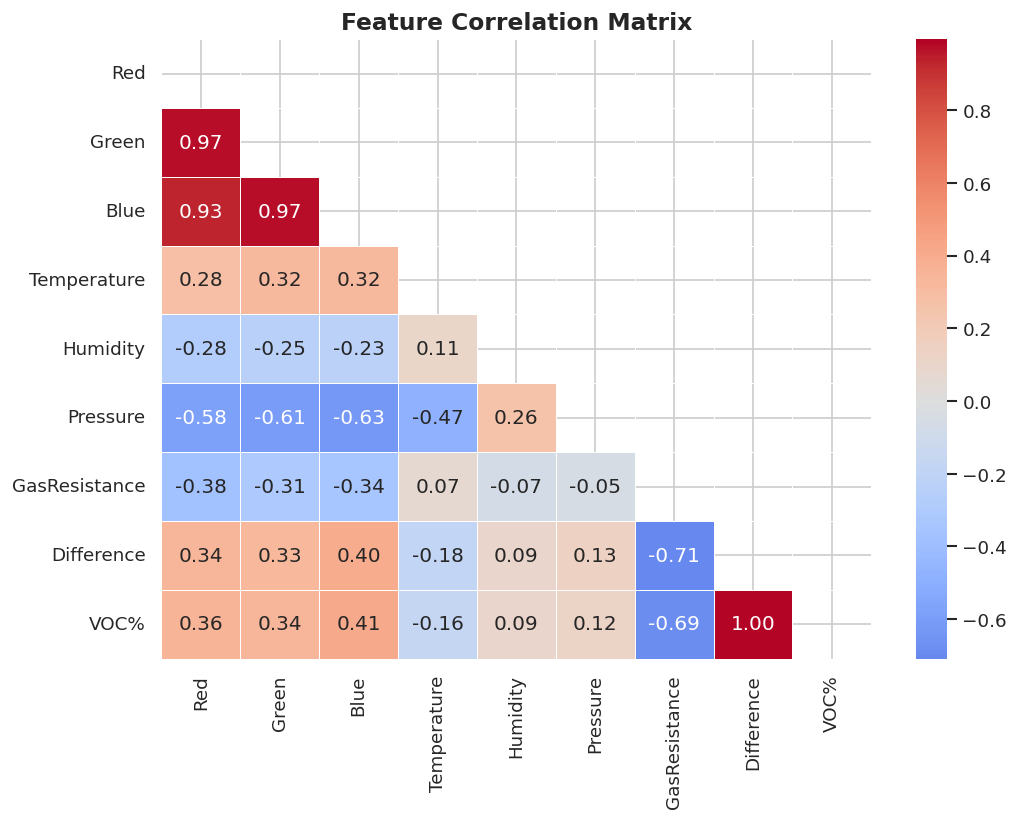

In [26]:
feature_cols = ['Red','Green','Blue','Temperature','Humidity',
                'Pressure','GasResistance','Difference','VOC%']

plt.figure(figsize=(9, 7))
corr = df[feature_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

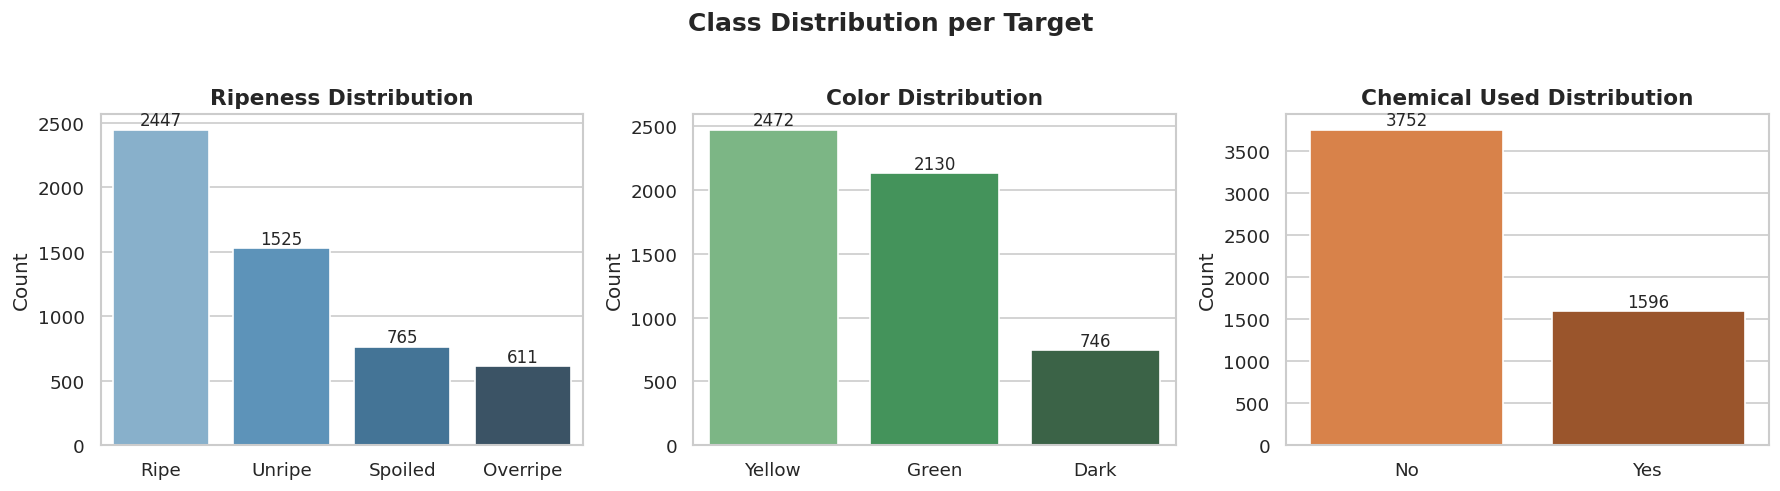


=== Imbalance Ratios (max / min class) ===
  Ripeness: 4.0x  {'Ripe': np.int64(2447), 'Unripe': np.int64(1525), 'Spoiled': np.int64(765), 'Overripe': np.int64(611)}
    ⚠️  High imbalance — SMOTE is important here
  Color: 3.3x  {'Yellow': np.int64(2472), 'Green': np.int64(2130), 'Dark': np.int64(746)}
    ⚠️  High imbalance — SMOTE is important here
  Chemical Used: 2.4x  {'No': np.int64(3752), 'Yes': np.int64(1596)}


In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

target_cols = ['Ripeness', 'Color', 'Chemical Used']
palettes    = ['Blues_d', 'Greens_d', 'Oranges_d']

for ax, col, pal in zip(axes, target_cols, palettes):
    counts = df[col].value_counts()
    sns.barplot(x=counts.index, y=counts.values, palette=pal, ax=ax)
    ax.set_title(f'{col} Distribution', fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    for bar, val in zip(ax.patches, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                str(val), ha='center', va='bottom', fontsize=10)

plt.suptitle('Class Distribution per Target', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n=== Imbalance Ratios (max / min class) ===')
for col in target_cols:
    counts = df[col].value_counts()
    ratio = counts.max() / counts.min()
    print(f'  {col}: {ratio:.1f}x  {dict(counts)}')
    if ratio > 3:
        print(f'    ⚠️  High imbalance — SMOTE is important here')

In [28]:
ripeness_encoder = LabelEncoder()
color_encoder    = LabelEncoder()
chemical_encoder = LabelEncoder()

y_ripeness = ripeness_encoder.fit_transform(df['Ripeness'])
y_color    = color_encoder.fit_transform(df['Color'])
y_chemical = chemical_encoder.fit_transform(df['Chemical Used'])

print('Ripeness classes :', ripeness_encoder.classes_)
print('Color classes    :', color_encoder.classes_)
print('Chemical classes :', chemical_encoder.classes_)

Ripeness classes : ['Overripe' 'Ripe' 'Spoiled' 'Unripe']
Color classes    : ['Dark' 'Green' 'Yellow']
Chemical classes : ['No' 'Yes']


In [29]:
FEATURES_RIPENESS = [
    'Humidity',
    'GasResistance', 'Difference',
    'Red', 'Green', 'Blue'
]
FEATURES_COLOR    = ['Red', 'Green', 'Blue']
FEATURES_CHEMICAL = [
    'Temperature', 'Humidity', 'Pressure',
    'GasResistance', 'Difference','VOC%',
    'Red', 'Green', 'Blue'
]

X_ripeness = df[FEATURES_RIPENESS].values
X_color    = df[FEATURES_COLOR].values
X_chemical = df[FEATURES_CHEMICAL].values

print(f'Total samples: {len(df)}')
print('Features set up ✅')

Total samples: 5348
Features set up ✅


In [30]:
TEST_SIZE   = 0.35
RANDOM_SEED = 42

X_train_r,  X_test_r,  y_train_r,  y_test_r  = train_test_split(
    X_ripeness, y_ripeness,
    test_size=TEST_SIZE, stratify=y_ripeness, random_state=RANDOM_SEED)

X_train_c,  X_test_c,  y_train_c,  y_test_c  = train_test_split(
    X_color, y_color,
    test_size=TEST_SIZE, stratify=y_color, random_state=RANDOM_SEED)

X_train_ch, X_test_ch, y_train_ch, y_test_ch = train_test_split(
    X_chemical, y_chemical,
    test_size=TEST_SIZE, stratify=y_chemical, random_state=RANDOM_SEED)

print(f'Ripeness  — Train: {X_train_r.shape[0]}, Test: {X_test_r.shape[0]}')
print(f'Color     — Train: {X_train_c.shape[0]}, Test: {X_test_c.shape[0]}')
print(f'Chemical  — Train: {X_train_ch.shape[0]}, Test: {X_test_ch.shape[0]}')

Ripeness  — Train: 3476, Test: 1872
Color     — Train: 3476, Test: 1872
Chemical  — Train: 3476, Test: 1872


## 5. Build Pipelines (SMOTE + XGBoost)

### ✅ Why use a Pipeline instead of applying SMOTE separately?

In v2, SMOTE was applied once before cross-validation. This causes **data leakage** — synthetic samples from the test fold bleed into training, making the model look better than it is.

With `imblearn.Pipeline`, SMOTE is **re-applied inside each CV fold**, only on the training portion. This gives honest accuracy estimates.

### ✅ Why reduce model complexity?

XGBoost with `max_depth=5` and 300 trees on a small dataset **memorizes** the data. We reduce to `max_depth=3`, fewer trees, and add `min_child_weight` to force the model to generalize.

In [31]:
def make_pipeline(objective, num_class=None):
    """Create an imblearn Pipeline: SMOTE → XGBoost.

    Key changes from v2:
    - max_depth reduced from 5 → 3  (less memorization)
    - n_estimators reduced from 300 → 150
    - min_child_weight=3 prevents splits on tiny leaf nodes
    - reg_lambda=1.5 adds L2 regularization
    """
    xgb_params = dict(
        n_estimators     = 40,
        learning_rate    = 0.05,
        max_depth        = 2,       # ✅ reduced from 5
        subsample        = 0.8,
        colsample_bytree = 0.8,
        min_child_weight = 3,       # ✅ new: avoids tiny leaf splits
        reg_lambda       = 1.5,     # ✅ new: L2 regularization
        objective        = objective,
        eval_metric      = ['mlogloss', 'merror'] if 'multi' in objective else ['logloss', 'error'],
        random_state     = RANDOM_SEED,
        verbosity        = 0,
    )
    if num_class:
        xgb_params['num_class'] = num_class

    return ImbPipeline([
        ('smote', SMOTE(random_state=RANDOM_SEED)),   # applied inside each fold ✅
        ('xgb',   XGBClassifier(**xgb_params))
    ])


ripeness_pipe  = make_pipeline('multi:softmax', num_class=len(ripeness_encoder.classes_))
color_pipe     = make_pipeline('multi:softmax', num_class=len(color_encoder.classes_))
chemical_pipe  = make_pipeline('binary:logistic')

print('✅ Pipelines created')

✅ Pipelines created


## 6. Cross-Validation (Proper — SMOTE inside each fold)

In [32]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

configs = [
    ('Ripeness', ripeness_pipe,  X_ripeness, y_ripeness),
    ('Color',    color_pipe,     X_color,    y_color),
    ('Chemical', chemical_pipe,  X_chemical, y_chemical),
]

cv_results = {}
print('Running 5-fold CV (SMOTE inside each fold)...\n')

for name, pipe, X, y in configs:
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    mean_acc = scores.mean()
    std_acc  = scores.std()
    flag = '⚠️  (suspiciously high — check for leakage or easy dataset)' if mean_acc > 0.98 else '✅'
    print(f'{name:10s} | CV Accuracy: {mean_acc:.4f} ± {std_acc:.4f}  '
          f'| Min: {scores.min():.4f}  Max: {scores.max():.4f}  {flag}')

Running 5-fold CV (SMOTE inside each fold)...

Ripeness   | CV Accuracy: 0.9153 ± 0.0196  | Min: 0.8840  Max: 0.9458  ✅
Color      | CV Accuracy: 0.9613 ± 0.0039  | Min: 0.9570  Max: 0.9664  ✅
Chemical   | CV Accuracy: 0.9645 ± 0.0129  | Min: 0.9411  Max: 0.9785  ✅


## 7. Train Final Models on Training Set

In [33]:
print('Training final models on training split...')
ripeness_pipe.fit(X_train_r,  y_train_r)
color_pipe.fit(X_train_c,    y_train_c)
chemical_pipe.fit(X_train_ch, y_train_ch)
print('✅ Done')

Training final models on training split...
✅ Done


## 8. Overfitting Diagnosis — Train vs Test Accuracy

**This is the most important check.** If train accuracy >> test accuracy, the model has overfit.

In [34]:
print('=' * 60)
print('  OVERFITTING DIAGNOSIS: Train vs Test Accuracy')
print('=' * 60)

eval_configs = [
    ('Ripeness', ripeness_pipe,  X_train_r,  y_train_r,  X_test_r,  y_test_r),
    ('Color',    color_pipe,     X_train_c,  y_train_c,  X_test_c,  y_test_c),
    ('Chemical', chemical_pipe,  X_train_ch, y_train_ch, X_test_ch, y_test_ch),
]

for name, pipe, Xtr, ytr, Xte, yte in eval_configs:
    train_acc = accuracy_score(ytr, pipe.predict(Xtr))
    test_acc  = accuracy_score(yte, pipe.predict(Xte))
    gap = train_acc - test_acc
    if gap > 0.10:
        status = '🔴 OVERFIT (gap > 10%)'
    elif gap > 0.05:
        status = '🟡 Mild overfit (gap 5-10%)'
    else:
        status = '🟢 Good generalization'
    print(f'{name:10s} | Train: {train_acc:.4f}  Test: {test_acc:.4f}  '
          f'Gap: {gap:+.4f}  {status}')

print()
print('If all test accuracies are 1.0, your dataset may be too small')
print('or too easy — try collecting more real-world variation.')

  OVERFITTING DIAGNOSIS: Train vs Test Accuracy
Ripeness   | Train: 0.9404  Test: 0.9327  Gap: +0.0078  🟢 Good generalization
Color      | Train: 0.9591  Test: 0.9663  Gap: -0.0072  🟢 Good generalization
Chemical   | Train: 0.9718  Test: 0.9663  Gap: +0.0055  🟢 Good generalization

If all test accuracies are 1.0, your dataset may be too small
or too easy — try collecting more real-world variation.


## 9. Learning Curves

Learning curves show train vs. validation accuracy as training data increases. A good model: both curves converge. An overfit model: huge gap between the two lines.

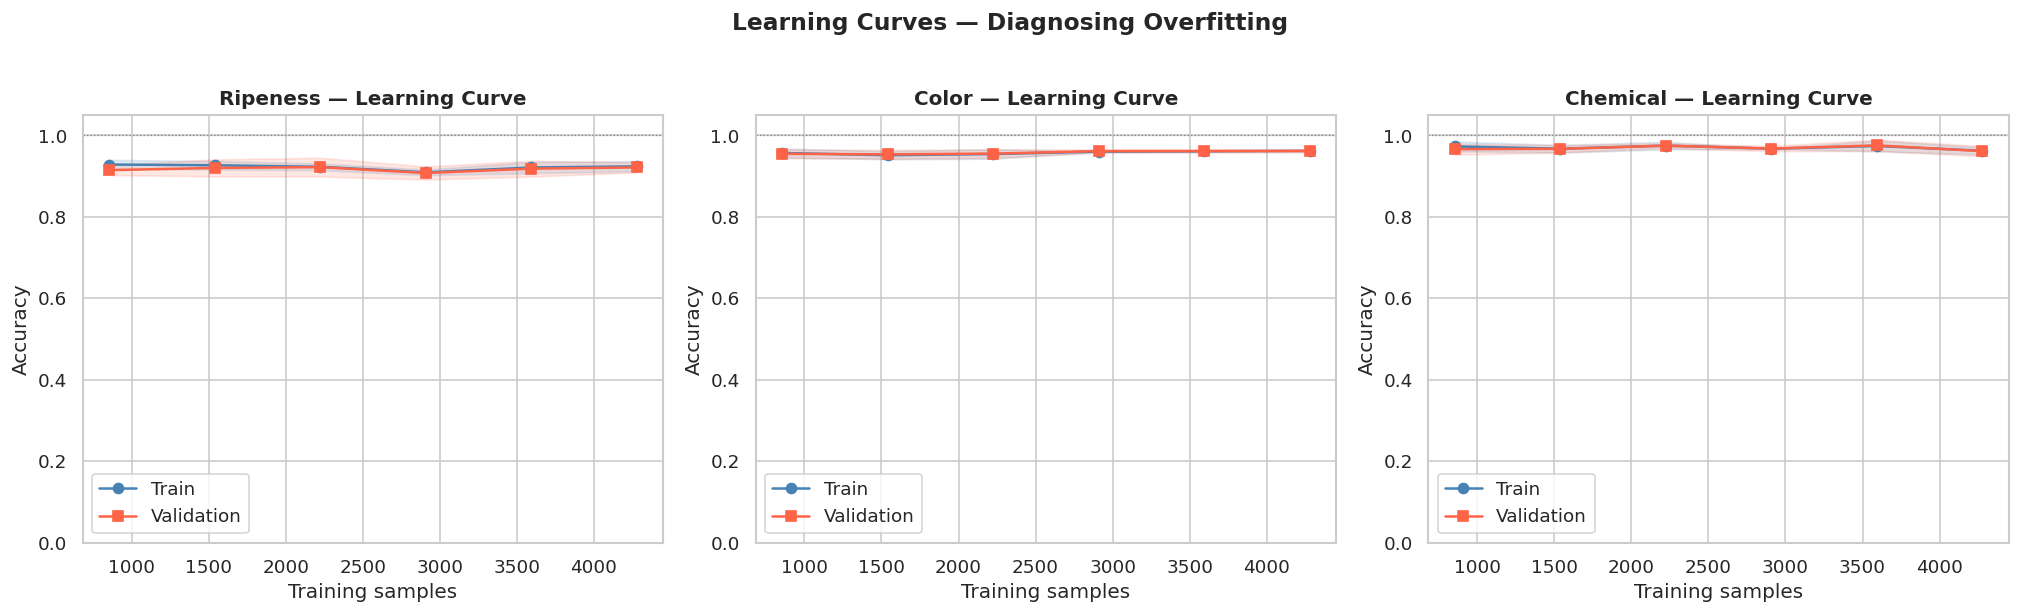

Interpretation:
  🟢 Both lines converging = good generalization
  🔴 Big gap between lines = model is overfitting
  🟡 Both lines plateau low = model needs more features or data


In [35]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

lc_configs = [
    ('Ripeness', ripeness_pipe,  X_ripeness, y_ripeness),
    ('Color',    color_pipe,     X_color,    y_color),
    ('Chemical', chemical_pipe,  X_chemical, y_chemical),
]

for ax, (name, pipe, X, y) in zip(axes, lc_configs):
    train_sizes, train_scores, val_scores = learning_curve(
        pipe, X, y,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
        train_sizes=np.linspace(0.2, 1.0, 6),
        scoring='accuracy',
        n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    val_mean   = val_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Train')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='steelblue')
    ax.plot(train_sizes, val_mean,   's-', color='tomato',    label='Validation')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='tomato')

    ax.set_title(f'{name} — Learning Curve', fontsize=12, fontweight='bold')
    ax.set_xlabel('Training samples')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.set_ylim(0, 1.05)
    ax.axhline(1.0, color='gray', linestyle=':', linewidth=0.8)

plt.suptitle('Learning Curves — Diagnosing Overfitting', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Interpretation:')
print('  🟢 Both lines converging = good generalization')
print('  🔴 Big gap between lines = model is overfitting')
print('  🟡 Both lines plateau low = model needs more features or data')

## 10. Test Set Evaluation

In [36]:
y_pred_r  = ripeness_pipe.predict(X_test_r)
y_pred_c  = color_pipe.predict(X_test_c)
y_pred_ch = chemical_pipe.predict(X_test_ch)

print('=' * 55)
print('RIPENESS MODEL')
print('=' * 55)
print(classification_report(y_test_r, y_pred_r, target_names=ripeness_encoder.classes_))

print('=' * 55)
print('COLOR MODEL')
print('=' * 55)
print(classification_report(y_test_c, y_pred_c, target_names=color_encoder.classes_))

print('=' * 55)
print('CHEMICAL MODEL')
print('=' * 55)
print(classification_report(y_test_ch, y_pred_ch, target_names=chemical_encoder.classes_))

RIPENESS MODEL
              precision    recall  f1-score   support

    Overripe       1.00      1.00      1.00       214
        Ripe       0.93      0.93      0.93       856
     Spoiled       0.82      1.00      0.90       268
      Unripe       0.99      0.89      0.93       534

    accuracy                           0.93      1872
   macro avg       0.93      0.95      0.94      1872
weighted avg       0.94      0.93      0.93      1872

COLOR MODEL
              precision    recall  f1-score   support

        Dark       1.00      1.00      1.00       261
       Green       0.98      0.93      0.96       746
      Yellow       0.94      0.98      0.96       865

    accuracy                           0.97      1872
   macro avg       0.98      0.97      0.97      1872
weighted avg       0.97      0.97      0.97      1872

CHEMICAL MODEL
              precision    recall  f1-score   support

          No       1.00      0.95      0.98      1313
         Yes       0.90      1.00

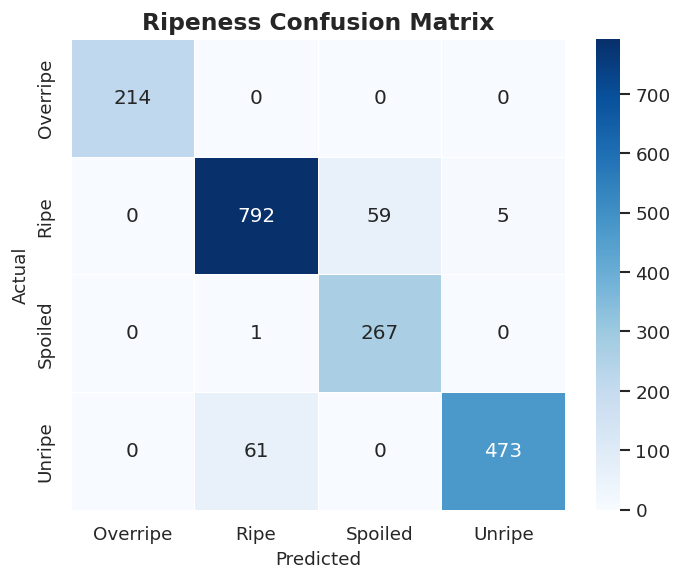

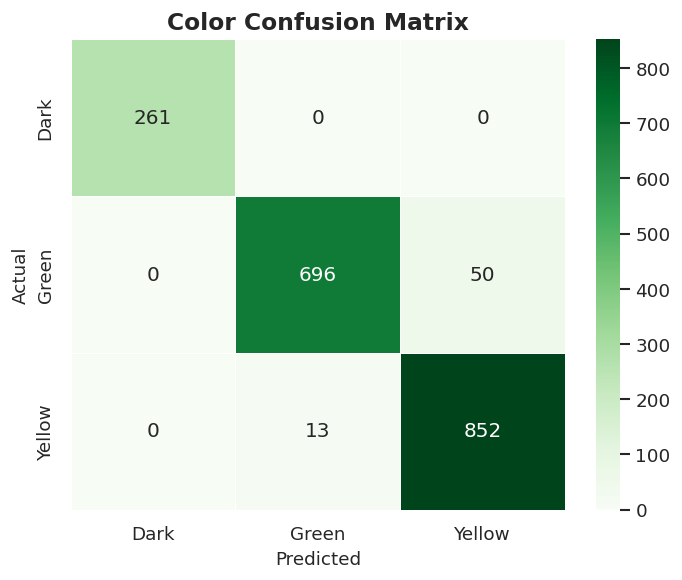

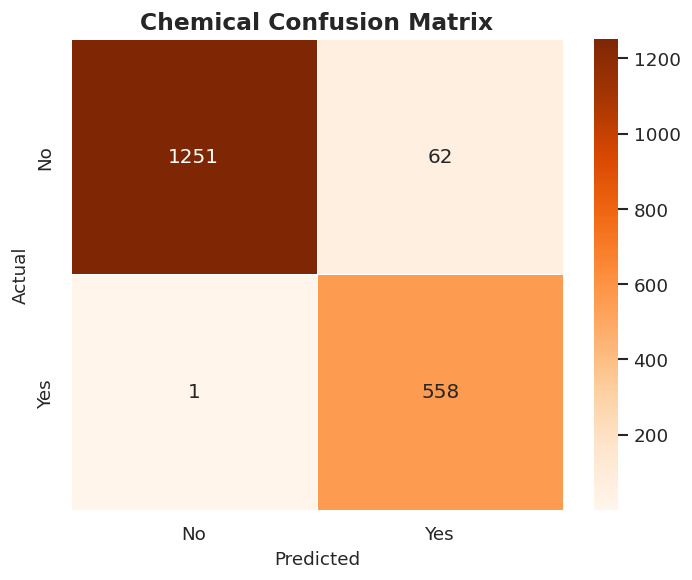

In [37]:
matrix_configs = [
    (y_test_r,  y_pred_r,  ripeness_encoder.classes_,  'Ripeness',  'Blues'),
    (y_test_c,  y_pred_c,  color_encoder.classes_,     'Color',     'Greens'),
    (y_test_ch, y_pred_ch, chemical_encoder.classes_,  'Chemical',  'Oranges'),
]

for y_true, y_pred, labels, title, cmap in matrix_configs:

    plt.figure(figsize=(6,5))

    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=cmap,
        xticklabels=labels,
        yticklabels=labels,
        linewidths=0.5,
        linecolor='white'
    )

    plt.title(
        f'{title} Confusion Matrix',
        fontsize=14,
        fontweight='bold'
    )

    plt.xlabel('Predicted', fontsize=11)
    plt.ylabel('Actual', fontsize=11)

    plt.tight_layout()
    plt.show()

## 11. Feature Importance

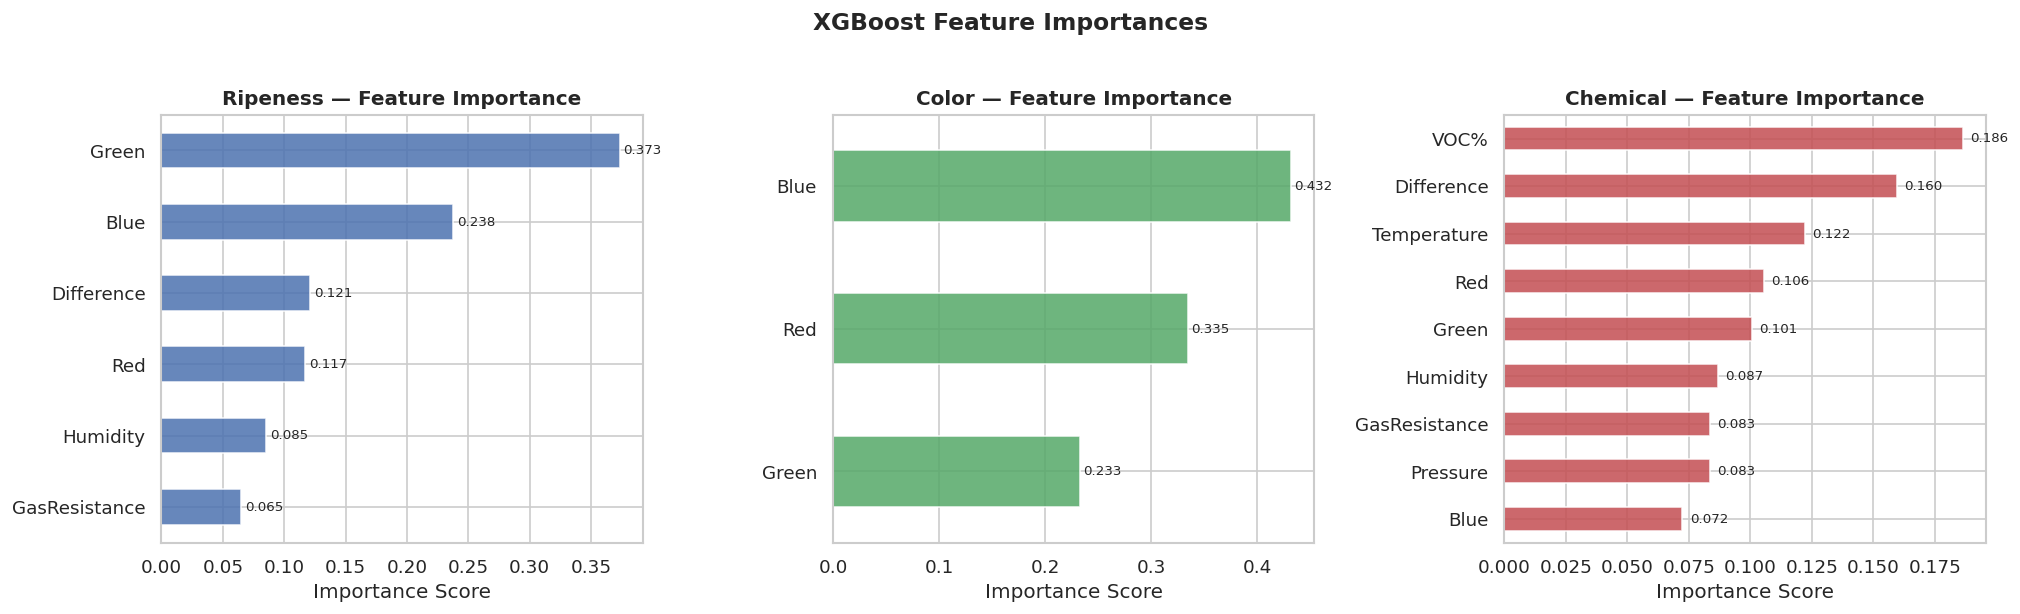

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

importance_configs = [
    (ripeness_pipe,  FEATURES_RIPENESS,  'Ripeness',  '#4C72B0'),
    (color_pipe,     FEATURES_COLOR,     'Color',     '#55A868'),
    (chemical_pipe,  FEATURES_CHEMICAL,  'Chemical',  '#C44E52'),
]

for ax, (pipe, features, title, color) in zip(axes, importance_configs):
    xgb_model = pipe.named_steps['xgb']
    imp = pd.Series(xgb_model.feature_importances_, index=features).sort_values()
    imp.plot(kind='barh', ax=ax, color=color, alpha=0.85)
    ax.set_title(f'{title} — Feature Importance', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance Score')
    for bar, val in zip(ax.patches, imp.values):
        ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)

plt.suptitle('XGBoost Feature Importances', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 12. Live Prediction

In [39]:
# 63,48,13,31.55,64.58,900.36,47.15,0.65,0.01
# 72,75,29,29.54,67.08,902.04,34.61,9.25,0.21
sample = {
    'Temperature'  : 29.54,
    'Humidity'     : 67.08,
    'Pressure'     :  902.04 ,
    'GasResistance': 34.61,
    'Difference'   : 9.25,
    'VOC%'         : 0.21,
    'Red'          : 72,
    'Green'        : 75,
    'Blue'         : 29,
}

input_r  = np.array([[sample[f] for f in FEATURES_RIPENESS]])
input_c  = np.array([[sample[f] for f in FEATURES_COLOR]])
input_ch = np.array([[sample[f] for f in FEATURES_CHEMICAL]])

pred_ripeness = ripeness_encoder.inverse_transform(ripeness_pipe.predict(input_r))[0]
pred_color    = color_encoder.inverse_transform(color_pipe.predict(input_c))[0]
pred_chemical = chemical_encoder.inverse_transform(chemical_pipe.predict(input_ch))[0]

prob_r  = ripeness_pipe.predict_proba(input_r)[0]
prob_c  = color_pipe.predict_proba(input_c)[0]
prob_ch = chemical_pipe.predict_proba(input_ch)[0]

print('=' * 45)
print('         LIVE PREDICTION RESULTS')
print('=' * 45)
print(f'  🍌 Ripeness  : {pred_ripeness}')
for cls, p in zip(ripeness_encoder.classes_, prob_r):
    print(f'       {cls:10s} — {p*100:.1f}%')
print()
print(f'  🎨 Color     : {pred_color}')
for cls, p in zip(color_encoder.classes_, prob_c):
    print(f'       {cls:10s} — {p*100:.1f}%')
print()
print(f'  🧪 Chemical  : {pred_chemical}')
for cls, p in zip(chemical_encoder.classes_, prob_ch):
    print(f'       {cls:10s} — {p*100:.1f}%')
print('=' * 45)

         LIVE PREDICTION RESULTS
  🍌 Ripeness  : Unripe
       Overripe   — 6.1%
       Ripe       — 16.0%
       Spoiled    — 11.6%
       Unripe     — 66.3%

  🎨 Color     : Green
       Dark       — 7.8%
       Green      — 83.7%
       Yellow     — 8.5%

  🧪 Chemical  : No
       No         — 94.3%
       Yes        — 5.7%


## 13. Save Models

In [40]:
joblib.dump(ripeness_pipe,    'ripeness_model (2).pkl')
joblib.dump(color_pipe,       'color_model (2).pkl')
joblib.dump(chemical_pipe,    'chemical_model (2).pkl')

joblib.dump(ripeness_encoder, 'ripeness_encoder.pkl')
joblib.dump(color_encoder,    'color_encoder.pkl')
joblib.dump(chemical_encoder, 'chemical_encoder.pkl')

print('✅ Pipelines saved (SMOTE + XGBoost bundled):')
print('   ripeness_pipeline.pkl  |  ripeness_encoder.pkl')
print('   color_pipeline.pkl     |  color_encoder.pkl')
print('   chemical_pipeline.pkl  |  chemical_encoder.pkl')
print()
print('Note: Use pipeline.predict() directly — no need to SMOTE at inference time.')

✅ Pipelines saved (SMOTE + XGBoost bundled):
   ripeness_pipeline.pkl  |  ripeness_encoder.pkl
   color_pipeline.pkl     |  color_encoder.pkl
   chemical_pipeline.pkl  |  chemical_encoder.pkl

Note: Use pipeline.predict() directly — no need to SMOTE at inference time.


In [41]:
# # Uncomment to download on Colab
# from google.colab import files
# for f in ["ripeness_model (2).pkl","color_model (2).pkl","chemical_model (2).pkl",
#           "ripeness_encoder.pkl","color_encoder.pkl","chemical_encoder.pkl"]:
#     files.download(f)



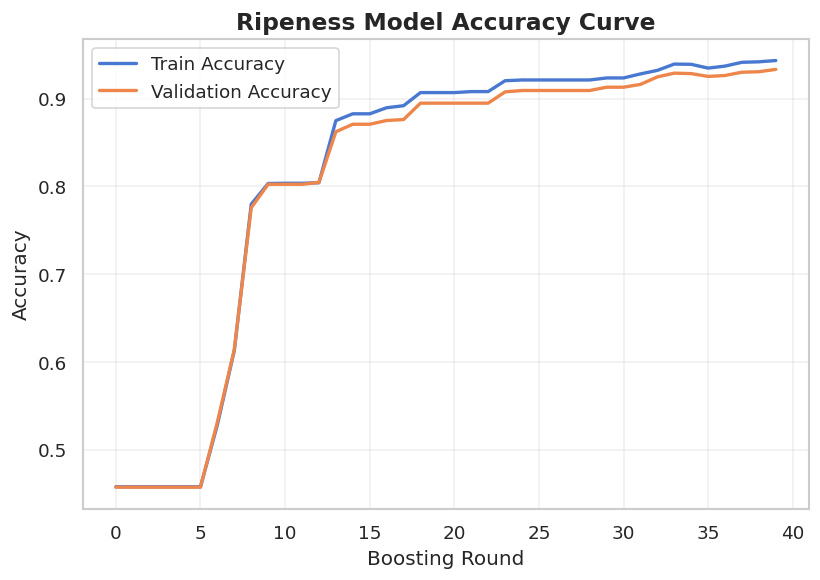

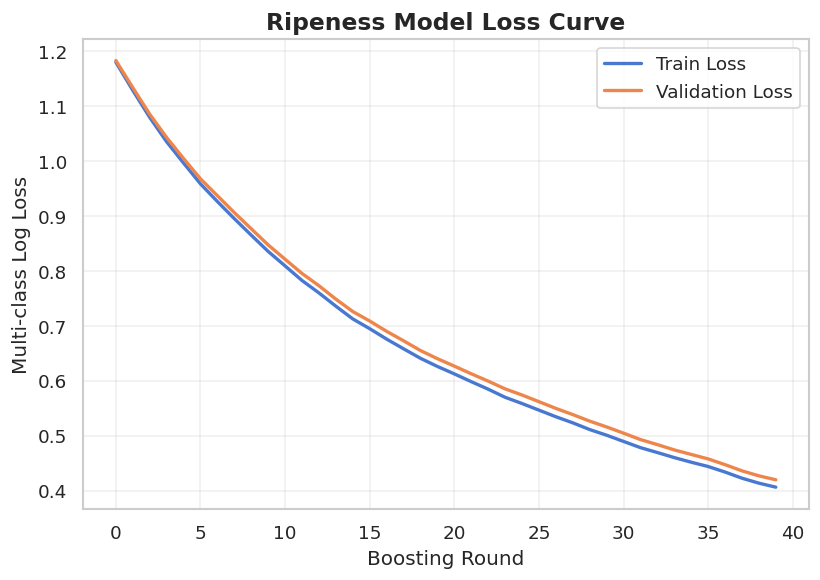

In [42]:
# =========================================================
# XGBOOST TRAINING CURVES
# =========================================================

# Access trained XGBoost model inside pipeline
xgb_model = ripeness_pipe.named_steps['xgb']

# Refit with evaluation tracking
xgb_model.fit(
    X_train_r,
    y_train_r,
    eval_set=[
        (X_train_r, y_train_r),
        (X_test_r, y_test_r)
    ],
    verbose=False
)

# Get evaluation history
results = xgb_model.evals_result()

# Number of boosting rounds
epochs = len(results['validation_0']['mlogloss'])
x_axis = range(epochs)

# =========================================================
# ACCURACY CURVE
# =========================================================

train_acc = [1 - x for x in results['validation_0']['merror']]
test_acc  = [1 - x for x in results['validation_1']['merror']]

plt.figure(figsize=(7,5))

plt.plot(
    x_axis,
    train_acc,
    label='Train Accuracy',
    linewidth=2
)

plt.plot(
    x_axis,
    test_acc,
    label='Validation Accuracy',
    linewidth=2
)

plt.title(
    'Ripeness Model Accuracy Curve',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Boosting Round')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# =========================================================
# LOSS CURVE
# =========================================================

plt.figure(figsize=(7,5))

plt.plot(
    x_axis,
    results['validation_0']['mlogloss'],
    label='Train Loss',
    linewidth=2
)

plt.plot(
    x_axis,
    results['validation_1']['mlogloss'],
    label='Validation Loss',
    linewidth=2
)

plt.title(
    'Ripeness Model Loss Curve',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Boosting Round')
plt.ylabel('Multi-class Log Loss')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

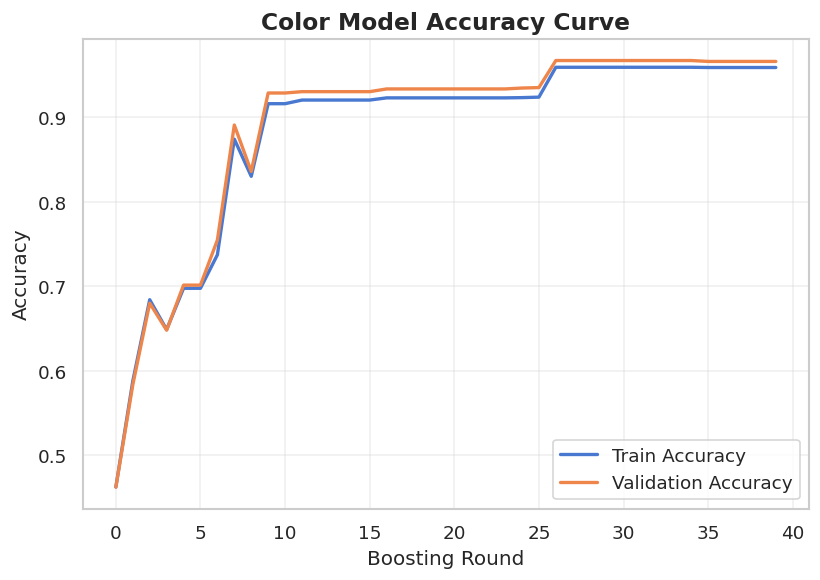

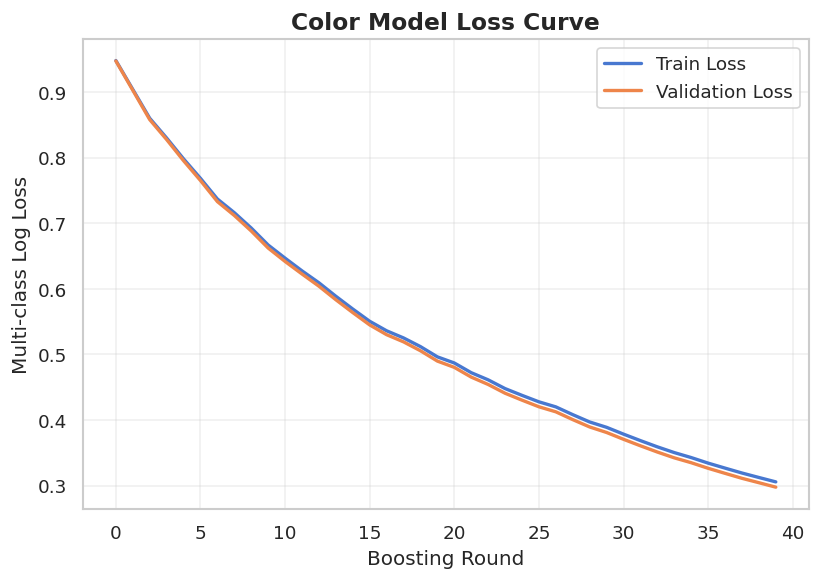

In [43]:
# =========================================================
# XGBOOST TRAINING CURVES — COLOR MODEL
# =========================================================

# Access trained XGBoost model inside pipeline
xgb_model = color_pipe.named_steps['xgb']

# Refit with evaluation tracking
xgb_model.fit(
    X_train_c,
    y_train_c,
    eval_set=[
        (X_train_c, y_train_c),
        (X_test_c, y_test_c)
    ],
    verbose=False
)

# Get evaluation history
results = xgb_model.evals_result()

# Number of boosting rounds
epochs = len(results['validation_0']['mlogloss'])
x_axis = range(epochs)

# =========================================================
# ACCURACY CURVE
# =========================================================

train_acc = [1 - x for x in results['validation_0']['merror']]
test_acc  = [1 - x for x in results['validation_1']['merror']]

plt.figure(figsize=(7,5))

plt.plot(
    x_axis,
    train_acc,
    label='Train Accuracy',
    linewidth=2
)

plt.plot(
    x_axis,
    test_acc,
    label='Validation Accuracy',
    linewidth=2
)

plt.title(
    'Color Model Accuracy Curve',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Boosting Round')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# =========================================================
# LOSS CURVE
# =========================================================

plt.figure(figsize=(7,5))

plt.plot(
    x_axis,
    results['validation_0']['mlogloss'],
    label='Train Loss',
    linewidth=2
)

plt.plot(
    x_axis,
    results['validation_1']['mlogloss'],
    label='Validation Loss',
    linewidth=2
)

plt.title(
    'Color Model Loss Curve',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Boosting Round')
plt.ylabel('Multi-class Log Loss')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

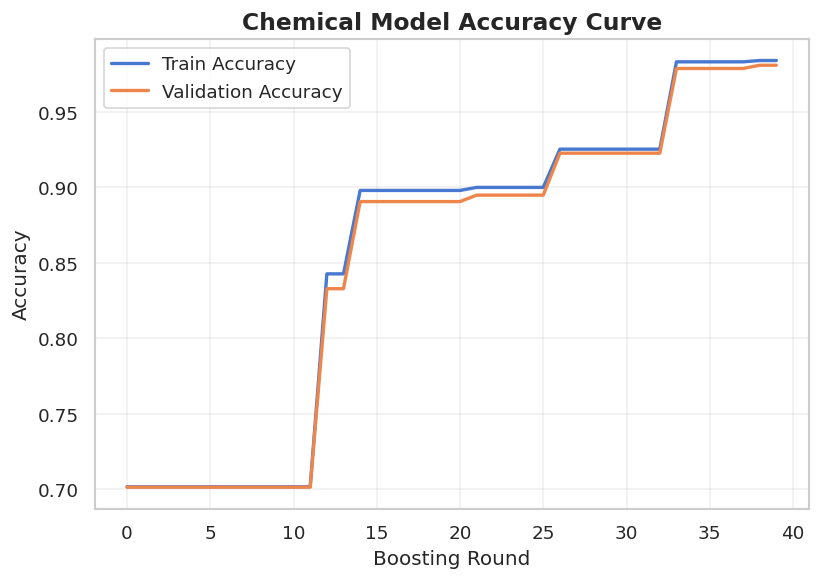

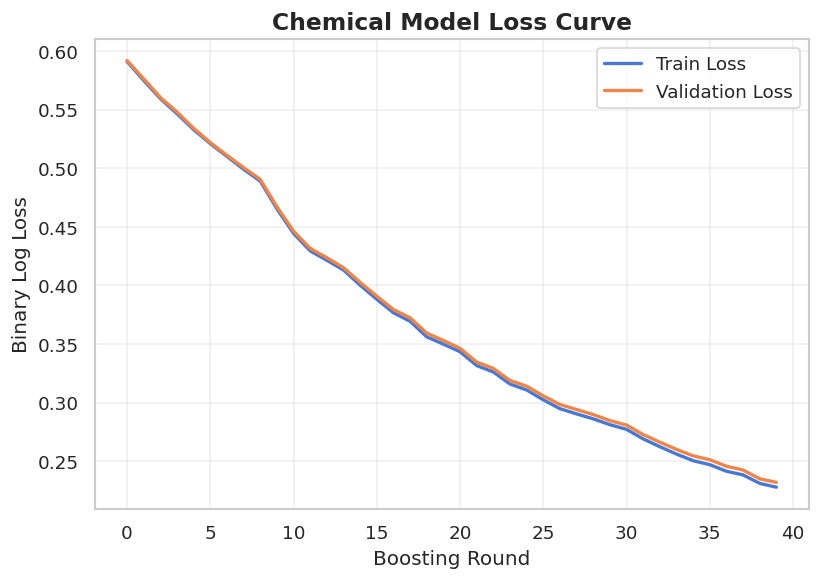

In [44]:
# =========================================================
# XGBOOST TRAINING CURVES — CHEMICAL MODEL
# =========================================================

# Access trained XGBoost model inside pipeline
xgb_model = chemical_pipe.named_steps['xgb']

# Refit with evaluation tracking
xgb_model.fit(
    X_train_ch,
    y_train_ch,
    eval_set=[
        (X_train_ch, y_train_ch),
        (X_test_ch, y_test_ch)
    ],
    verbose=False
)

# Get evaluation history
results = xgb_model.evals_result()

# Number of boosting rounds
epochs = len(results['validation_0']['logloss'])
x_axis = range(epochs)

# =========================================================
# ACCURACY CURVE
# =========================================================

train_acc = [1 - x for x in results['validation_0']['error']]
test_acc  = [1 - x for x in results['validation_1']['error']]

plt.figure(figsize=(7,5))

plt.plot(
    x_axis,
    train_acc,
    label='Train Accuracy',
    linewidth=2
)

plt.plot(
    x_axis,
    test_acc,
    label='Validation Accuracy',
    linewidth=2
)

plt.title(
    'Chemical Model Accuracy Curve',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Boosting Round')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# =========================================================
# LOSS CURVE
# =========================================================

plt.figure(figsize=(7,5))

plt.plot(
    x_axis,
    results['validation_0']['logloss'],
    label='Train Loss',
    linewidth=2
)

plt.plot(
    x_axis,
    results['validation_1']['logloss'],
    label='Validation Loss',
    linewidth=2
)

plt.title(
    'Chemical Model Loss Curve',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Boosting Round')
plt.ylabel('Binary Log Loss')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()